# Customer Segmentation using K-Means Clustering
---



This project analyzes customer behavior based on Annual Income and Spending Score.  
The goal is to segment customers into distinct groups to help businesses make better marketing decisions.

## Objective

To analyze customer behavior and segment them into meaningful groups based on income and spending patterns.

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

## Data Loading

The dataset is loaded and inspected to understand its structure.

In [32]:
df = pd.read_csv("/store_customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0


## Data Understanding

We check the structure and basic statistics of the dataset.

In [33]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              1000 non-null   int64  
 1   Gender                  997 non-null    object 
 2   Age                     994 non-null    float64
 3   Annual Income (k$)      996 non-null    float64
 4   Spending Score (1-100)  994 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 39.2+ KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,1000.000000,994.000000,996.000000,994.000000
mean,1499.500000,38.935614,57.149096,42.645875
std,288.819436,13.399880,28.628506,20.101589
min,1000.000000,18.000000,15.000000,1.000000
25%,1249.750000,30.000000,34.975000,31.000000
50%,1499.500000,36.000000,49.000000,47.000000
75%,1749.250000,44.000000,79.400000,57.000000
max,1999.000000,80.000000,144.100000,92.000000


## Data Preparation

We select relevant features for clustering:
- Annual Income  
- Spending Score  

In [34]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

## Data Cleaning

The dataset contained missing values.  
Since K-Means cannot handle missing data, these rows are removed.

In [35]:
X.isnull().sum()

,0
Annual Income (k$),4
Spending Score (1-100),6


In [36]:
X = X.dropna()

In [37]:
X.isnull().sum()

,0
Annual Income (k$),0
Spending Score (1-100),0


## Data Visualization

We plot Annual Income vs Spending Score to understand customer distribution and identify potential clusters.

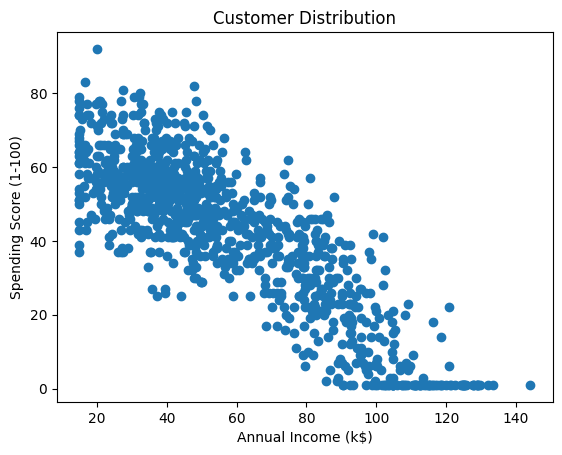

In [38]:
plt.scatter(X['Annual Income (k$)'], X['Spending Score (1-100)'])
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Distribution")
plt.show()

### Observation

The scatter plot shows visible groupings of customers, indicating that clustering techniques can be applied.

### Elbow Method

To determine the optimal number of clusters, we use the Elbow Method.  
It calculates the WCSS (Within Cluster Sum of Squares) for different numbers of clusters.  

The optimal number of clusters is where the decrease in WCSS starts slowing down, forming an "elbow" shape in the graph.

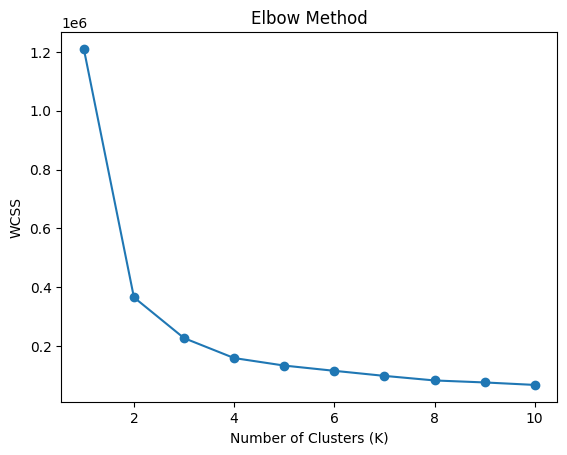

In [39]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

### Elbow Method Observation

The Elbow Method graph shows a sharp decrease in WCSS up to K = 4, after which the rate of decrease slows down significantly.  

This indicates that 4 clusters is the optimal number for segmenting the customers, as adding more clusters does not provide substantial improvement.


### K-Means Clustering

Based on the Elbow Method, the optimal number of clusters is 4.  

K-Means clustering is applied to group customers into 4 segments based on their Annual Income and Spending Score.  

This helps in identifying different types of customers with similar behavior patterns.

In [40]:
kmeans = KMeans(n_clusters=4, random_state=42)
y_kmeans = kmeans.fit_predict(X)

## Cluster Visualization

Customers are visualized with different colors, and cluster centers are highlighted.

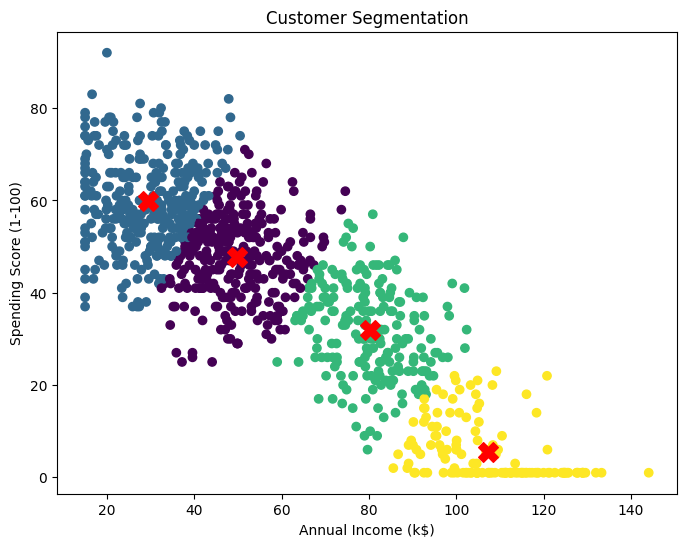

In [42]:
plt.figure(figsize=(8,6))
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y_kmeans)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=200, c='red', marker='X')

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segmentation")
plt.show()

## Final Insights

The clustering results show four distinct customer groups:

- Low income, high spending → highly engaged but potentially risky customers  
- Medium income, medium spending → stable and consistent customers  
- High income, moderate spending → strong potential for growth  
- High income, low spending → underutilized customers needing engagement  

The cluster centers represent the average position of each group, helping to clearly define customer behavior patterns.

These insights can help businesses design targeted marketing strategies, improve engagement, and increase revenue.